In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ppghr.io import ACTIVITIES, PROJECT_ROOT
from ppghr.features import FEATURE_NAMES

d = np.load(PROJECT_ROOT / "results" / "metrics" / "predictions.npz")
y, groups, act = d["y"], d["groups"], d["act"]
pred_full, pred_acc, pred_ppg, baseline = d["pred_full"], d["pred_acc"], d["pred_ppg"], d["baseline"]

with open(PROJECT_ROOT / "results" / "metrics" / "loso_results.json") as f:
    results = json.load(f)

print(f"{len(y)} windows, {len(np.unique(groups))} subjects")
print(f"full model LOSO MAE: {np.abs(pred_full - y).mean():.2f}")

64697 windows, 15 subjects
full model LOSO MAE: 8.34


In [2]:
import pickle
with open(PROJECT_ROOT / "data" / "processed" / "features.pkl", "rb") as f:
    X = pickle.load(f)["X"]
print(X.shape)

(64697, 21)


In [3]:
rows = []
for code in sorted(set(act.tolist())):
    if code < 0:
        continue
    m = act == code
    rows.append({
        "activity": ACTIVITIES[code],
        "n": int(m.sum()),
        "mean_hr": y[m].mean(),
        "baseline": np.abs(X[m, -2] - y[m]).mean(),
        "acc_only": np.abs(pred_acc[m] - y[m]).mean(),
        "ppg_only": np.abs(pred_ppg[m] - y[m]).mean(),
        "full": np.abs(pred_full[m] - y[m]).mean(),
    })

import pandas as pd
df = pd.DataFrame(rows).sort_values("full")
print(df.to_string(index=False, float_format=lambda v: f"{v:6.2f}"))

    activity     n  mean_hr  baseline  acc_only  ppg_only   full
     sitting  4517    60.97      2.96     13.72      7.70   4.09
     working  8450    76.30      5.99      9.43      6.36   4.46
       lunch 13498    83.54      9.36     11.33      7.56   5.85
     driving  6788    84.64      8.81     12.70      7.57   6.36
   transient 17103    94.73     17.42     15.60     11.49   9.75
     walking  4643    99.30     23.53     13.06     12.89  11.55
     cycling  3424   123.47     23.49     24.25     18.97  12.86
table_soccer  2258    90.44     24.38     15.18     13.97  13.82
      stairs  3185   119.12     31.81     23.34     24.77  17.88


In [4]:
base_err = np.abs(X[:, -2] - y)
full_err = np.abs(pred_full - y)

catastrophic = base_err > 20
print(f"baseline errors >20 bpm: {catastrophic.sum()} windows ({catastrophic.mean()*100:.1f}%)")
print(f"  of those, model error: {full_err[catastrophic].mean():.2f} bpm")
print(f"model errors >20 bpm:    {(full_err>20).sum()} windows ({(full_err>20).mean()*100:.1f}%)")
print(f"\nbaseline median: {np.median(base_err):.2f}   model median: {np.median(full_err):.2f}")

baseline errors >20 bpm: 15325 windows (23.7%)
  of those, model error: 19.16 bpm
model errors >20 bpm:    7747 windows (12.0%)

baseline median: 4.05   model median: 3.80


In [5]:
from xgboost import XGBRegressor

m = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 objective="reg:absoluteerror", n_jobs=-1)
m.fit(X, y)

imp = sorted(zip(FEATURE_NAMES, m.feature_importances_), key=lambda t: -t[1])
for name, v in imp:
    print(f"{name:22s} {v:.4f}")

baseline_est_bpm       0.3346
accy_peak_pow          0.1471
prev_baseline_bpm      0.0891
ppg_peak1_bpm          0.0723
ppg_peak2_bpm          0.0639
acc_total_energy       0.0498
accz_peak_pow          0.0307
ppg_entropy            0.0288
accx_peak_pow          0.0261
ppg_peak3_bpm          0.0219
accx_peak_bpm          0.0164
accy_peak_bpm          0.0157
accz_peak_bpm          0.0138
ppg2_to_acc_dist       0.0132
ppg1_to_acc_dist       0.0128
ppg_band_power         0.0124
ppg_pow3               0.0122
ppg_pow2               0.0113
ppg_pow1               0.0100
ppg3_to_acc_dist       0.0099
ppg_peak_ratio         0.0079


In [6]:
from ppghr.io import load_subject

meta = {}
for sid in np.unique(groups):
    q = load_subject(int(sid))["questionnaire"]
    meta[int(sid)] = {
        "skin": q.get("SKIN"), "age": q.get("AGE"),
        "gender": str(q.get("Gender", "")).strip(), "sport": q.get("SPORT"),
        "mae": float(np.abs(pred_full[groups == sid] - y[groups == sid]).mean()),
    }

dfm = pd.DataFrame(meta).T.sort_values("mae")
print(dfm.to_string())

for col in ["skin", "age", "sport"]:
    v = pd.to_numeric(dfm[col], errors="coerce")
    print(f"{col:6s} vs MAE: r = {np.corrcoef(v, dfm['mae'].astype(float))[0,1]:+.3f}")

   skin age gender sport        mae
7     3  21      f     2   3.870333
14    3  26      f     4   4.403288
13    3  21      f     6   4.869872
3     3  25      m     5   4.906134
15    2  28      m     5   5.484009
10    4  55      f     5   5.517515
2     3  28      m     5   5.897292
4     4  25      m     5   7.290648
1     3  34      m     6   8.200986
6     3  37      f     1   8.344754
9     4  28      f     5   8.884088
11    3  24      f     5   10.77728
8     3  43      m     5   11.75006
12    3  43      m     5  14.042085
5     3  21      f     4  21.512808
skin   vs MAE: r = -0.017
age    vs MAE: r = +0.051
sport  vs MAE: r = +0.010


In [7]:
from sklearn.model_selection import LeaveOneGroupOut
from xgboost import XGBRegressor

def loso_eval(X, y, groups, feature_idx=None, verbose=False):
    cols = slice(None) if feature_idx is None else feature_idx
    pred = np.zeros(len(y))
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        m = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         objective="reg:absoluteerror", n_jobs=-1)
        m.fit(X[tr][:, cols], y[tr])
        pred[te] = m.predict(X[te][:, cols])
        if verbose:
            print(f"  S{groups[te][0]:<2} {np.abs(pred[te]-y[te]).mean():5.2f}")
    return pred

names = list(FEATURE_NAMES)
no_base = [i for i, n in enumerate(names) if n not in ("baseline_est_bpm", "prev_baseline_bpm")]
print(f"{len(no_base)} features, dropped: baseline_est_bpm, prev_baseline_bpm\n")

pred_nb = loso_eval(X, y, groups, feature_idx=no_base, verbose=True)
print(f"\nfull model      {np.abs(pred_full - y).mean():.2f}")
print(f"without baseline {np.abs(pred_nb - y).mean():.2f}")

19 features, dropped: baseline_est_bpm, prev_baseline_bpm

  S1   9.31
  S2   6.09
  S3   5.64
  S4   6.86
  S5  27.16
  S6  13.13
  S7   4.63
  S8  11.74
  S9   8.86
  S10  6.12
  S11 11.41
  S12 15.83
  S13  5.16
  S14  5.18
  S15  6.14

full model      8.34
without baseline 9.42


In [8]:
m_nb = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    objective="reg:absoluteerror", n_jobs=-1)
m_nb.fit(X[:, no_base], y)

imp_nb = sorted(zip([names[i] for i in no_base], m_nb.feature_importances_),
                key=lambda t: -t[1])
for n, v in imp_nb[:10]:
    print(f"{n:22s} {v:.4f}")

ppg_peak1_bpm          0.2227
ppg_peak2_bpm          0.1666
accy_peak_pow          0.1490
acc_total_energy       0.1051
accz_peak_pow          0.0603
ppg_entropy            0.0437
ppg_peak3_bpm          0.0416
accx_peak_pow          0.0352
ppg1_to_acc_dist       0.0205
accy_peak_bpm          0.0198


In [9]:
FIG = PROJECT_ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

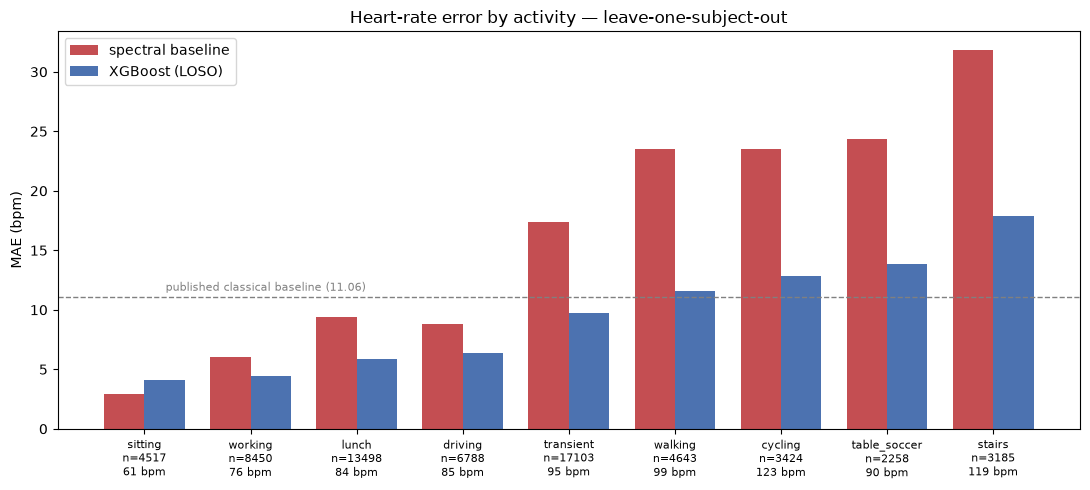

In [14]:
order = ["sitting", "working", "lunch", "driving", "transient",
         "walking", "cycling", "table_soccer", "stairs"]
code_of = {v: k for k, v in ACTIVITIES.items()}

base_v, full_v, ns, hrs = [], [], [], []
for a in order:
    m = act == code_of[a]
    base_v.append(np.abs(baseline[m] - y[m]).mean())
    full_v.append(np.abs(pred_full[m] - y[m]).mean())
    ns.append(m.sum()); hrs.append(y[m].mean())

xp = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(xp - w/2, base_v, w, label="spectral baseline", color="#c44e52")
ax.bar(xp + w/2, full_v, w, label="XGBoost (LOSO)", color="#4c72b0")
ax.axhline(11.06, ls="--", c="gray", lw=1)
ax.text(0.2, 11.6, "published classical baseline (11.06)", fontsize=8, color="gray")
ax.set_xticks(xp)
ax.set_xticklabels([f"{a}\nn={n}\n{h:.0f} bpm" for a, n, h in zip(order, ns, hrs)], fontsize=8)
ax.set_ylabel("MAE (bpm)")
ax.set_title("Heart-rate error by activity — leave-one-subject-out")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "mae_by_activity.png", dpi=150)
plt.show()

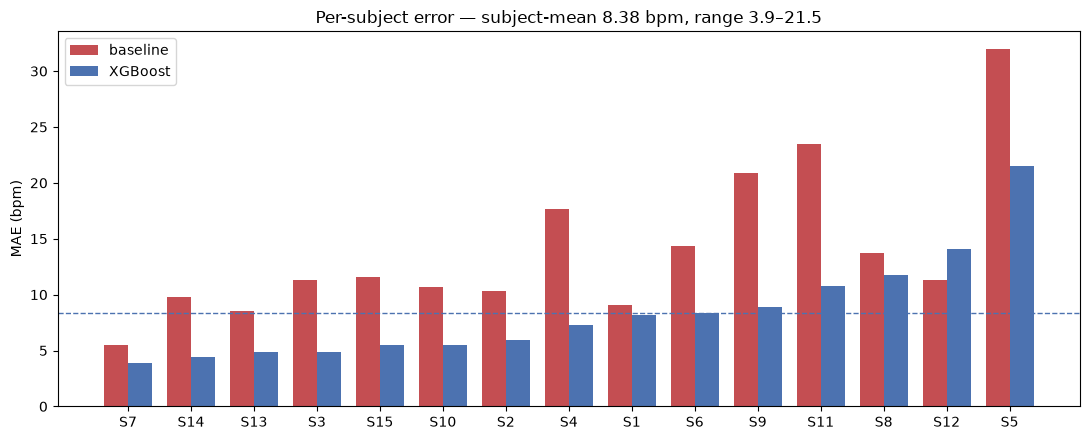

In [15]:
sids = np.unique(groups)
sb = np.array([np.abs(baseline[groups==s] - y[groups==s]).mean() for s in sids])
sf = np.array([np.abs(pred_full[groups==s] - y[groups==s]).mean() for s in sids])
o = np.argsort(sf)

fig, ax = plt.subplots(figsize=(11, 4.5))
xp = np.arange(len(sids))
ax.bar(xp - 0.19, sb[o], 0.38, label="baseline", color="#c44e52")
ax.bar(xp + 0.19, sf[o], 0.38, label="XGBoost", color="#4c72b0")
ax.axhline(sf.mean(), ls="--", c="#4c72b0", lw=1)
ax.set_xticks(xp); ax.set_xticklabels([f"S{s}" for s in sids[o]])
ax.set_ylabel("MAE (bpm)")
ax.set_title(f"Per-subject error — subject-mean {sf.mean():.2f} bpm, range {sf.min():.1f}–{sf.max():.1f}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "mae_by_subject.png", dpi=150)
plt.show()

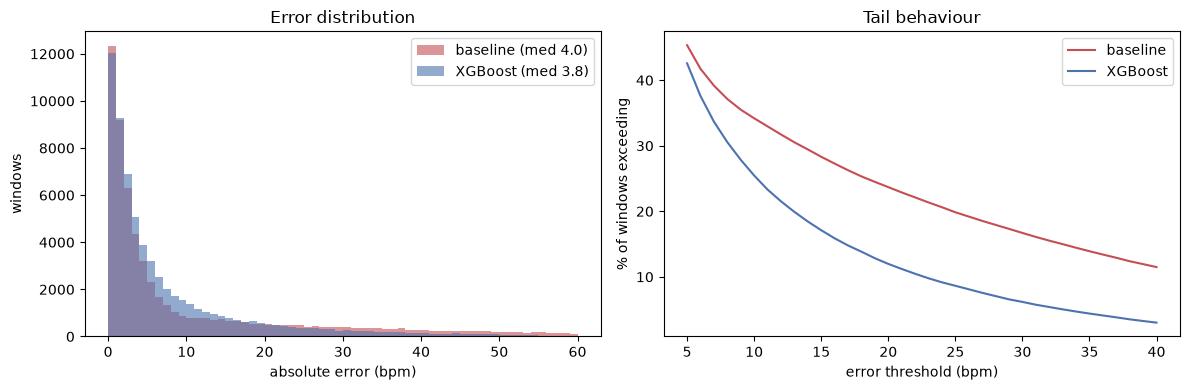

In [12]:
be, fe = np.abs(baseline - y), np.abs(pred_full - y)
bins = np.linspace(0, 60, 61)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(be, bins, alpha=0.6, label=f"baseline (med {np.median(be):.1f})", color="#c44e52")
axes[0].hist(fe, bins, alpha=0.6, label=f"XGBoost (med {np.median(fe):.1f})", color="#4c72b0")
axes[0].set_xlabel("absolute error (bpm)"); axes[0].set_ylabel("windows")
axes[0].legend(); axes[0].set_title("Error distribution")

th = np.arange(5, 41)
axes[1].plot(th, [(be > t).mean()*100 for t in th], color="#c44e52", label="baseline")
axes[1].plot(th, [(fe > t).mean()*100 for t in th], color="#4c72b0", label="XGBoost")
axes[1].set_xlabel("error threshold (bpm)"); axes[1].set_ylabel("% of windows exceeding")
axes[1].legend(); axes[1].set_title("Tail behaviour")
plt.tight_layout()
plt.savefig(FIG / "error_distribution.png", dpi=150)
plt.show()

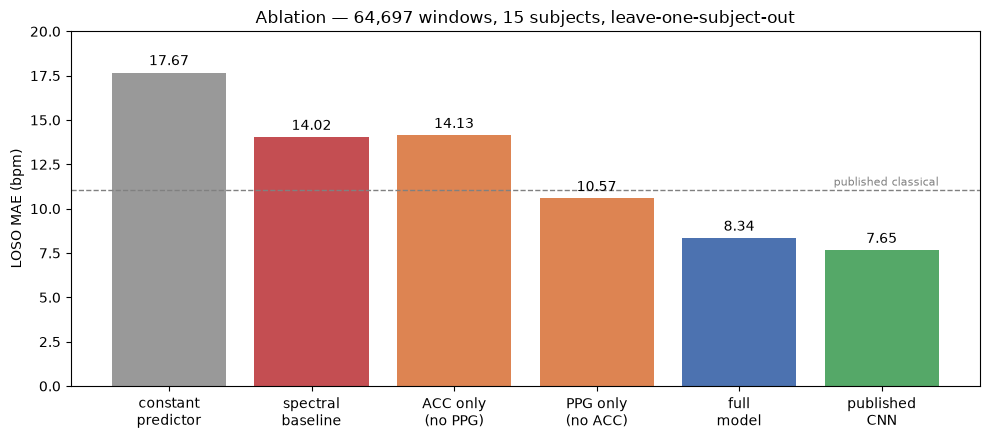

In [13]:
labels_ = ["constant\npredictor", "spectral\nbaseline", "ACC only\n(no PPG)",
           "PPG only\n(no ACC)", "full\nmodel", "published\nCNN"]
vals = [results["overall"]["constant_predictor"], results["overall"]["baseline_loso"],
        results["overall"]["xgb_acc_only_loso"], results["overall"]["xgb_ppg_only_loso"],
        results["overall"]["xgb_full_loso"], 7.65]
cols = ["#999999", "#c44e52", "#dd8452", "#dd8452", "#4c72b0", "#55a868"]

fig, ax = plt.subplots(figsize=(10, 4.5))
b = ax.bar(labels_, vals, color=cols)
ax.bar_label(b, fmt="%.2f", padding=3)
ax.axhline(11.06, ls="--", c="gray", lw=1)
ax.text(5.4, 11.3, "published classical", ha="right", fontsize=8, color="gray")
ax.set_ylabel("LOSO MAE (bpm)"); ax.set_ylim(0, 20)
ax.set_title("Ablation — 64,697 windows, 15 subjects, leave-one-subject-out")
plt.tight_layout()
plt.savefig(FIG / "ablation.png", dpi=150)
plt.show()